# Time Series Analysis of Building Energy Data

Building L is an academic building for a university in California. For such building types, energy consumption is typically accounted for by lighting systems and heating, ventilation and cooling (HVAC) systems. For this project, I was interested in using Python to develop a model to predict a building's energy consumption based on data that are usually publicly available such as outside air temperature. In addiiton, depending on building type and building use, there are generally also noticeable pattern such as seasonality. In the summer, when the outside air temperature is higher, air conditionining systems which are electric-powered are operated more to maintain a certain setpoint. In the winter on the other hand, when the outside temperature is lower, heating systems, which may be gas or electric-powered are operated to maintain a certain setpoint.

Thus, in general, we would expect to see higher building energy consumption during the summer in comparison to the winter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import datetime

import statsmodels.api as sm
import itertools
import warnings
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf
from sklearn.metrics import mean_squared_error
plt.style.use('fivethirtyeight')

In [2]:
#Read in the data from Excel
df = pd.read_excel('Building L Energy Data.xlsx')

In [3]:
#Check the structure of the dataframe
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81832 entries, 0 to 81831
Data columns (total 6 columns):
Timestamp                           81832 non-null datetime64[ns]
YearMonth                           81832 non-null object
TOL_Outside Air Temperature (°F)    81832 non-null float64
L_PWR_Electric_Total (kW)           81832 non-null float64
Electricity (kWh)                   81832 non-null float64
Year                                81832 non-null int64
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 3.7+ MB


,Timestamp,YearMonth,TOL_Outside Air Temperature (°F),L_PWR_Electric_Total (kW),Electricity (kWh),Year
0,2012-10-01 00:00:00,12 10,64.031000,1109.68,277.42,2012
1,2012-10-01 00:15:00,12 10,64.491000,1119.36,279.84,2012
2,2012-10-01 00:30:00,12 10,65.203000,1147.52,286.88,2012
3,2012-10-01 00:45:00,12 10,65.503000,1136.96,284.24,2012
4,2012-10-01 01:00:00,12 10,65.119426,1142.24,285.56,2012


From a quick review of the table above, I noted that the data is in 15-minute intervals, which is common for electric utilities. In addition, the dataset includes the following columns:

1) Year and Month
2) Outside air ambient temperature (F)
3) Electric power draw (kW)
4) Electricity consumption (kWh)
5) Year

In [4]:
#Drop YearMonth Column
df.drop('YearMonth',axis=1,inplace=True)

In [5]:
#Rename the headings for easier reference
df.columns = ['timestamp','OAT','kW','kWh','Year']

In [6]:
df.set_index('timestamp',inplace=True)

## Explanatory Data Analysis (EDA) 

### 15-Minute Interval Plot 

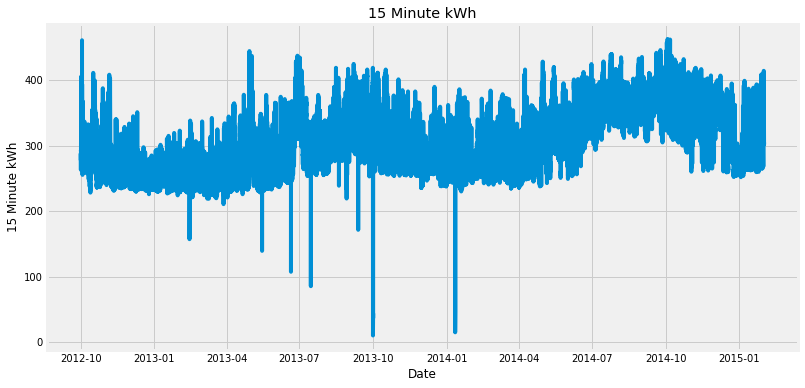

In [6]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(df['kWh'])

ax.set_title('15 Minute kWh')
ax.set(xlabel='Date', ylabel='15 Minute kWh');

15-minute kWh data shows that there appears to be a slight overall increasing trend, and that there are seasonality in the data. There are also differences in variance over time. In addition, significant lower data point may suggest outliers; These are particularly noticeable around October 2013 and January 2014. This plot shows that the 15-minute kWh data is not stationary (i.e. not a constant mean, variance and covariance.

### Hourly Plot

In [7]:
hourly_df = df.resample('h').sum()

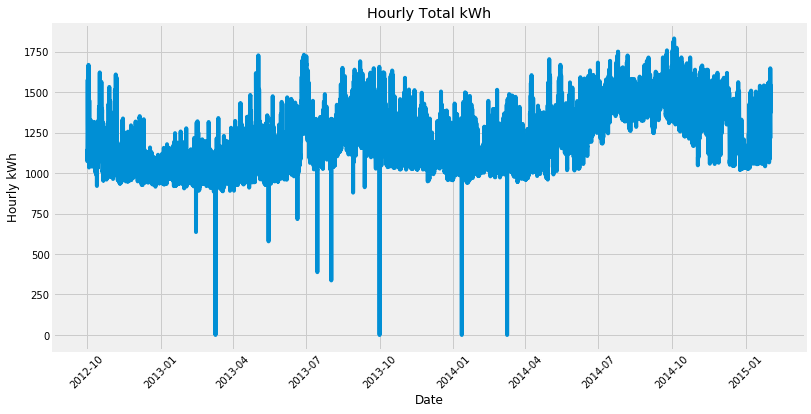

In [8]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(hourly_df['kWh'])

ax.set_title('Hourly Total kWh')
ax.set(xlabel='Date', ylabel='Hourly kWh')

ax.tick_params(axis = 'x', rotation = 45)

The plot above is similar to what is plotted for the 15-minute inteval data.

### Daily Plot

In [9]:
daily_df = df.resample('D').sum()

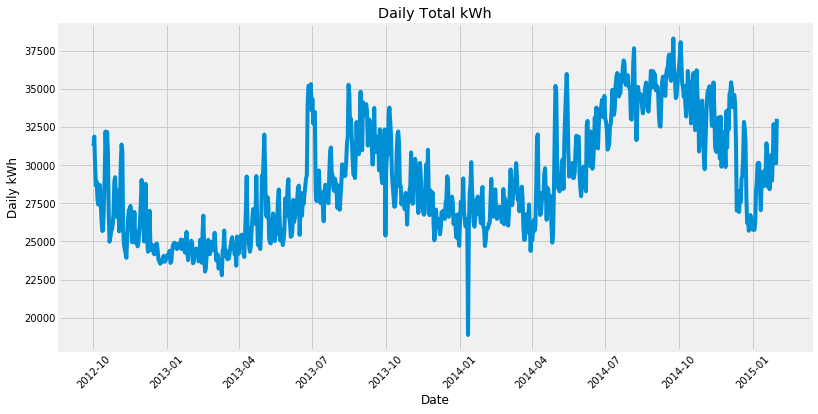

In [ ]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(daily_df['kWh'])

ax.set_title('Daily Total kWh')
ax.set(xlabel='Date', ylabel='Daily kWh')

ax.tick_params(axis = 'x', rotation = 45)

The above plot shows the aggregated kWh on a daily basis. Similar to the 15-minute plot, this plot shows that there appears to be an overall increasing trend, and that there are seasonality and cycles in the data. For instance, the peak total kWh in 2014 was around the 37,500 kWh mark, whereas in 2013, the peak total kWh was around 35,000 kWh. There are also differences in variance over time. In addition, significant lower data points may suggest outliers. These show the daily kWh is not stationary.

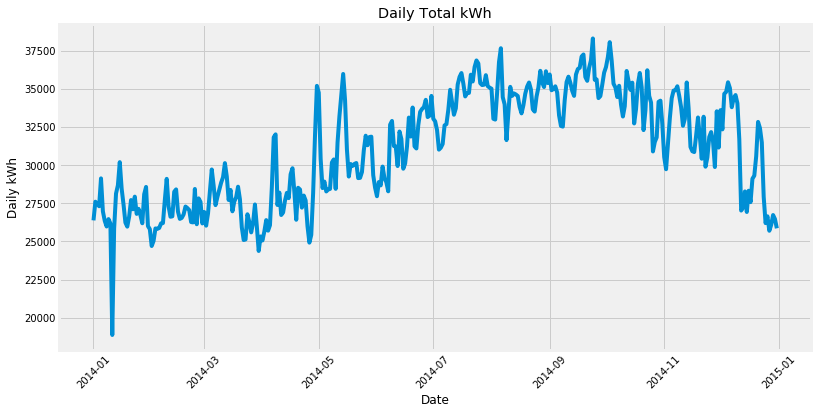

In [11]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(daily_df['kWh']['2014-01-01':'2014-12-31'])

ax.set_title('Daily Total kWh')
ax.set(xlabel='Date', ylabel='Daily kWh')

ax.tick_params(axis = 'x', rotation = 45)

### Monthly Plot 

In [12]:
monthly_df = df.resample('M').sum()

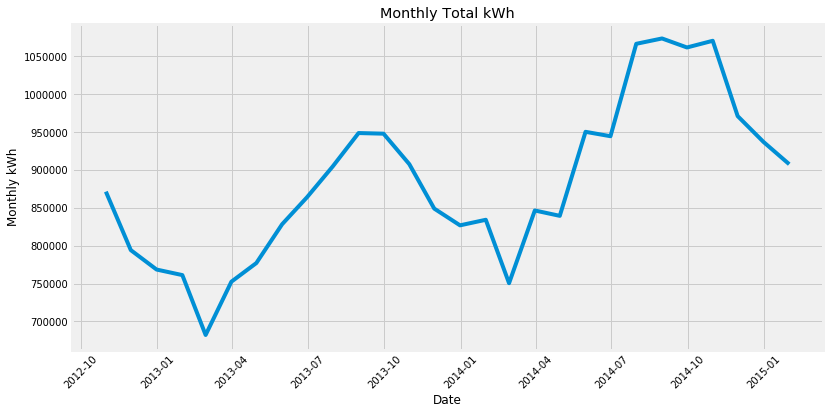

In [13]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(monthly_df['kWh'])

ax.set_title('Monthly Total kWh')
ax.set(xlabel='Date', ylabel='Monthly kWh')

ax.tick_params(axis = 'x', rotation = 45)

This plot show seasonality and an upward trend. The monthly kWh trend shows energy usage typically peaks during September and October and valleys during March.

## Determining Stationarity

Stationarity is the underlying assumption for time-series models. In particular, stationarity assumes that the time-series has:
<br>
- Constant mean
<br>
- Constant variance
<br>
- Autocovariance does not depend on time
<br>
    
This allows for the assumption that future trends can be forecasted/predicted using historical data. The 15-minute, daily and monthly kWh plots above indicate that these plots are non-stationary; however statistical tests can also be performed on such data to check for stationarity. Stationary is explained briefly here: https://en.wikipedia.org/wiki/Stationary_process

The two statistical tests that will be performed are:
<br>
- Augmented Dickey Fuller test (ADF)
<br>
- Kwiakowski-Pillips-Schmidt-Shin test (KPSS)
<br>
    
Both these statistical tests are unit root tests to determine whether the time series variable is non-stationary.
<br> <br>
The KPSS test has a null hypothesis that the time series is stationary around a deterministic trend (trend stationary). Hence, by not rejecting the KPSS null hypothesis, the time series is taken to be trend stationary. 
<br><br>
The ADF test has a null hypothesis that a unit root is present in a time series (i.e. the time series is not stationary). The ADF statistic is a negative number - the more negative the test statistic, the strong the rejection of the null hypothesis.
<br><br>
Let's use a alpha value of 0.01 in evaluating these tests.

### Augmented Dickey Fuller test (ADF) 

In [14]:
 def ADF_test(df,ts):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(df[ts], 
                      autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], 
                         index = ['Test Statistic',
                                  'p-value',
                                  '# Lags Used',
                                  'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)

### Kwiakowski-Pillips-Schmidt-Shin test (KPSS)

In [15]:
#define function for kpss test

#define KPSS
def KPSS_test(df,ts):
    print ('Results of KPSS Test:')
    kpsstest = kpss(df[ts], regression='c')
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)

#### 15-Minute Data

In [16]:
ADF_test(df = df, ts = 'kWh')

Results of Dickey-Fuller Test:
Test Statistic                -8.612366e+00
p-value                        6.424423e-14
# Lags Used                    6.500000e+01
Number of Observations Used    8.176600e+04
Critical Value (1%)           -3.430430e+00
Critical Value (5%)           -2.861575e+00
Critical Value (10%)          -2.566789e+00
dtype: float64


In [17]:
KPSS_test(df = df, ts = 'kWh')

Results of KPSS Test:
Test Statistic           50.311418
p-value                   0.010000
Lags Used                65.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Python\lib\site-packages\statsmodels\tsa\stattools.py:1276: InterpolationWarning: p-value is smaller than the indicated p-value
  warn("p-value is smaller than the indicated p-value", InterpolationWarning)


ADF: p-value (6.424x10^(-14)) < alpha value (0.01). Null hypothesis is rejected, and the series is stationary.

KPSS: p-value (<0.01) < alpha value (0.01). Null hypothesis is rejected, and the series is not stationary.

#### Hourly Data

In [18]:
ADF_test(df = hourly_df, ts = 'kWh')

Results of Dickey-Fuller Test:
Test Statistic                    -4.579598
p-value                            0.000141
# Lags Used                       46.000000
Number of Observations Used    20425.000000
Critical Value (1%)               -3.430670
Critical Value (5%)               -2.861682
Critical Value (10%)              -2.566845
dtype: float64


In [19]:
KPSS_test(df = hourly_df, ts = 'kWh')

Results of KPSS Test:
Test Statistic           19.386912
p-value                   0.010000
Lags Used                46.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Python\lib\site-packages\statsmodels\tsa\stattools.py:1276: InterpolationWarning: p-value is smaller than the indicated p-value
  warn("p-value is smaller than the indicated p-value", InterpolationWarning)


ADF: p-value (0.000141) < alpha value (0.01). Null hypothesis is rejected, and the series is stationary.

KPSS: p-value (<0.01) < alpha value (0.01). Null hypothesis is rejected, and the series is not stationary.

#### Daily Data

In [20]:
ADF_test(df = daily_df, ts = 'kWh')

Results of Dickey-Fuller Test:
Test Statistic                  -1.809340
p-value                          0.375834
# Lags Used                     12.000000
Number of Observations Used    840.000000
Critical Value (1%)             -3.438159
Critical Value (5%)             -2.864987
Critical Value (10%)            -2.568605
dtype: float64


In [21]:
KPSS_test(df = daily_df, ts = 'kWh')

Results of KPSS Test:
Test Statistic            2.068875
p-value                   0.010000
Lags Used                21.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Python\lib\site-packages\statsmodels\tsa\stattools.py:1276: InterpolationWarning: p-value is smaller than the indicated p-value
  warn("p-value is smaller than the indicated p-value", InterpolationWarning)


ADF: p-value (0.375834) > alpha value (0.01). Null hypothesis is retained, and the series is not stationary.

KPSS: p-value (less than 0.01) < alpha value (0.01). Null hypothesis is rejected, and the series is not stationary.

#### Monthly Data

In [22]:
ADF_test(df = monthly_df, ts = 'kWh')

Results of Dickey-Fuller Test:
Test Statistic                  1.228884
p-value                         0.996179
# Lags Used                     9.000000
Number of Observations Used    18.000000
Critical Value (1%)            -3.859073
Critical Value (5%)            -3.042046
Critical Value (10%)           -2.660906
dtype: float64


In [23]:
KPSS_test(df = monthly_df, ts = 'kWh')

Results of KPSS Test:
Test Statistic           0.381702
p-value                  0.085042
Lags Used                9.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


ADF: p-value (0.996179) > alpha value (0.01). Null hypothesis is retained, and the series is not stationary.

KPSS: p-value (0.085042) > alpha value (0.01). Null hypothesis is retained, and the series is trend stationary.

Through these tests, we can conclude the the original data (in 15 minute intervals) and the aggregated data are not stationary.

## Analysis on Daily Data

Let's use the daily data in our analysis. ADF and KPSS tests imply the time series is not stationary. Let's use differencing and see if this makes the time series stationary.

In [24]:
daily_df = df.resample('D').sum()

In [25]:
#shifting by 7 days
daily_df['kWh_diff'] = daily_df['kWh'] - daily_df['kWh'].shift(1)

In [26]:
daily_df.dropna(inplace=True)

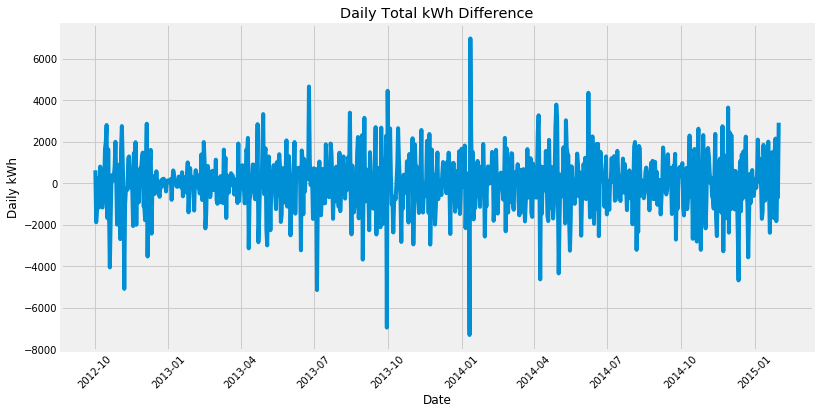

In [27]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(daily_df['kWh_diff'])

ax.set_title('Daily Total kWh Difference')
ax.set(xlabel='Date', ylabel='Daily kWh')

ax.tick_params(axis = 'x', rotation = 45)

This looks better in terms of stationarity, however, let's apply to ADF and KPSS tests once again on the time series after differencing.

In [28]:
ADF_test(df = daily_df, ts = 'kWh_diff')

Results of Dickey-Fuller Test:
Test Statistic                -1.339358e+01
p-value                        4.714916e-25
# Lags Used                    1.100000e+01
Number of Observations Used    8.400000e+02
Critical Value (1%)           -3.438159e+00
Critical Value (5%)           -2.864987e+00
Critical Value (10%)          -2.568605e+00
dtype: float64


In [29]:
KPSS_test(df = daily_df, ts = 'kWh_diff')

Results of KPSS Test:
Test Statistic            0.068854
p-value                   0.100000
Lags Used                21.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


C:\Python\lib\site-packages\statsmodels\tsa\stattools.py:1278: InterpolationWarning: p-value is greater than the indicated p-value
  warn("p-value is greater than the indicated p-value", InterpolationWarning)


ADF: p-value (0.0000) < alpha value (0.01). Null hypothesis is rejected, and the series is stationary.

KPSS: p-value (>0.1) > alpha value (0.01). Null hypothesis is retained, and the series is stationary.

After differencing, both the ADF and KPSS tests show that the daily time-series data is stationary.

## ACF and PACF Plots 

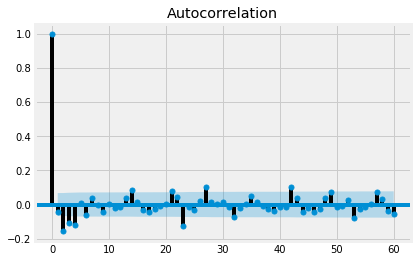

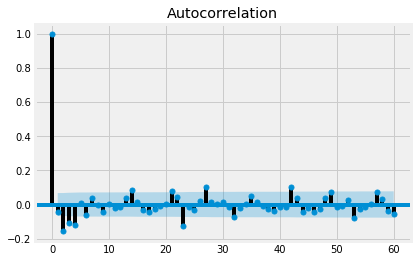

In [30]:
plot_acf(daily_df['kWh_diff'],lags=60)

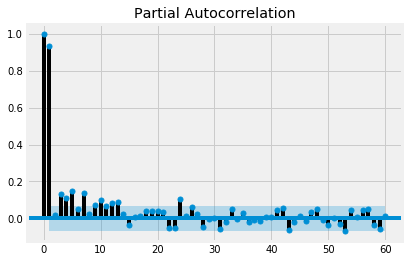

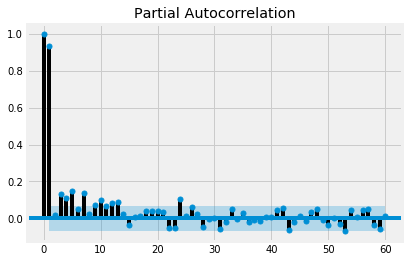

In [31]:
plot_pacf(daily_df['kWh'],lags=60)

## Seasonal ARIMA Model  

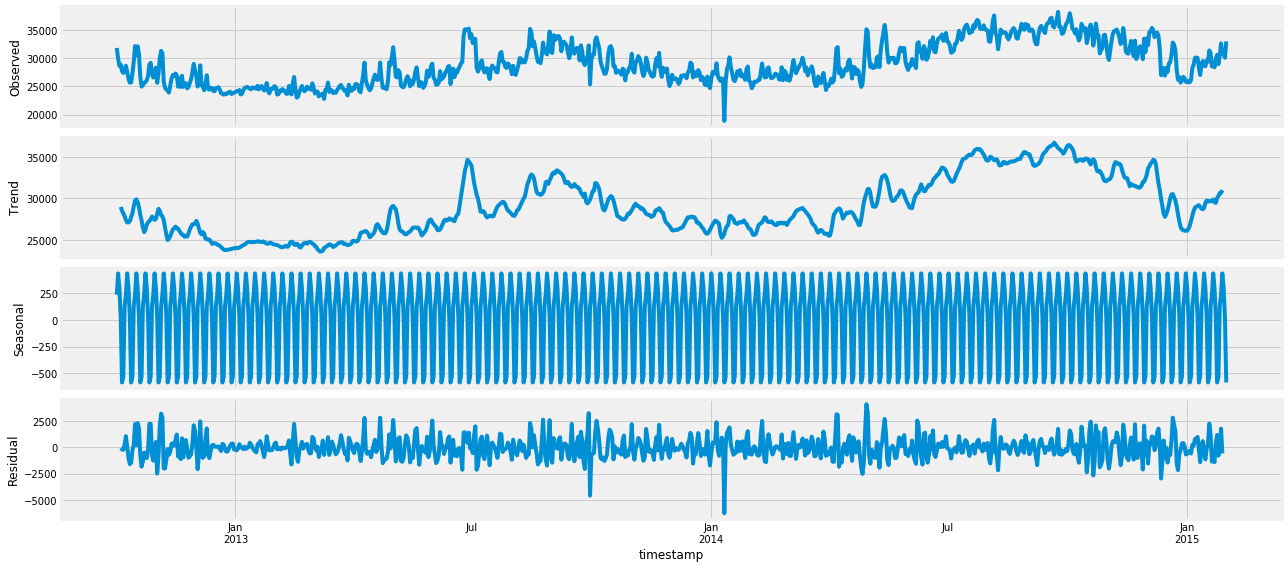

In [32]:
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(daily_df['kWh'], model='additive')
fig = decomposition.plot()
plt.show()

To model the daily kWh data for this building, let's start with a Seasaonal Auto Regressive Integrative Moving Average (SARIMA) model. 

### Parameter Selecter (p,d,q) and (P,D,Q)

In [33]:
daily_df = df.resample('D').sum()
daily_df['kWh_diff'] = daily_df['kWh'] - daily_df['kWh'].shift(7)

In [34]:
train = daily_df['kWh'][0:-30]

In [35]:
test = daily_df['kWh'][-30:]

In [36]:
# Define the p, d and q parameters to take any value between 0 and 2
p = d = q  = range(0, 2)

# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, q and q triplets
seasonal_pdq = [(x[0], x[1], x[2],7) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 7)
SARIMAX: (0, 0, 1) x (0, 1, 0, 7)
SARIMAX: (0, 1, 0) x (0, 1, 1, 7)
SARIMAX: (0, 1, 0) x (1, 0, 0, 7)


In [ ]:
warnings.filterwarnings("ignore") # specify to ignore warning messages

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

            results = mod.fit()

            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

In [ ]:
##Best from above is:

##ARIMA(1, 0, 0)x(1, 1, 1, 24)12 - AIC:204443.57480789587

In [ ]:
# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 3)

# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# Generate all different combinations of seasonal p, q and q triplets
seasonal_pdq = [(x[0], x[1], x[2], 7) for x in list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

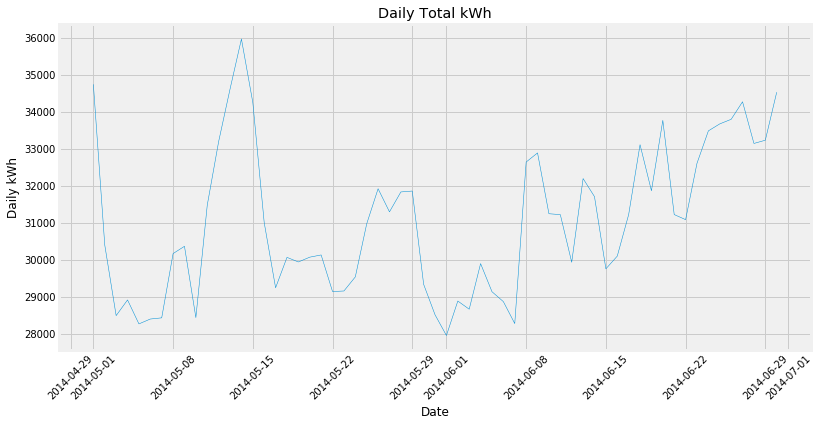

In [37]:
figure, ax = plt.subplots(1,1,figsize=(12,6))
ax.plot(daily_df['kWh']['2014-05-01':'2014-06-30'], lw = 0.5)

ax.set_title('Daily Total kWh')
ax.set(xlabel='Date', ylabel='Daily kWh')

ax.tick_params(axis = 'x', rotation = 45)

In [38]:
train = daily_df['kWh'][0:-30]
test = daily_df['kWh'][-30:]

In [39]:
warnings.filterwarnings("ignore") # specify to ignore warning messages

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(train,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

            results = mod.fit()

            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

ARIMA(0, 0, 0)x(0, 0, 0, 7)12 - AIC:19239.19934537312
ARIMA(0, 0, 0)x(0, 0, 1, 7)12 - AIC:18512.711528504384
ARIMA(0, 0, 0)x(0, 1, 0, 7)12 - AIC:15032.786916639161
ARIMA(0, 0, 0)x(0, 1, 1, 7)12 - AIC:14696.21921203948
ARIMA(0, 0, 0)x(1, 0, 0, 7)12 - AIC:15051.458711010266
ARIMA(0, 0, 0)x(1, 0, 1, 7)12 - AIC:14885.54978245688
ARIMA(0, 0, 0)x(1, 1, 0, 7)12 - AIC:14697.874003197436
ARIMA(0, 0, 0)x(1, 1, 1, 7)12 - AIC:14670.153900593512
ARIMA(0, 0, 1)x(0, 0, 0, 7)12 - AIC:18617.003007616793
ARIMA(0, 0, 1)x(0, 0, 1, 7)12 - AIC:18326.550253945017
ARIMA(0, 0, 1)x(0, 1, 0, 7)12 - AIC:14599.787011657238
ARIMA(0, 0, 1)x(0, 1, 1, 7)12 - AIC:14213.588044814021
ARIMA(0, 0, 1)x(1, 0, 1, 7)12 - AIC:14420.265801531572
ARIMA(0, 0, 1)x(1, 1, 0, 7)12 - AIC:14291.311392182633
ARIMA(0, 0, 1)x(1, 1, 1, 7)12 - AIC:14205.359722943624
ARIMA(0, 1, 0)x(0, 0, 0, 7)12 - AIC:14179.11426136549
ARIMA(0, 1, 0)x(0, 0, 1, 7)12 - AIC:14061.801524349126
ARIMA(0, 1, 0)x(0, 1, 0, 7)12 - AIC:14590.203963190514
ARIMA(0, 1, 0)

In [40]:
##Best from above is:

##ARIMA(1, 0, 1)x(1, 1, 1, 24)12 - AIC:202610.66242356482

mod = sm.tsa.statespace.SARIMAX(train,
                                order=(1,1,1),
                                seasonal_order=(1,2,2,28),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()
print(results.summary().tables[1])

#(1,1,2)x(1,2,2,60)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5559      0.151     -3.694      0.000      -0.851      -0.261
ma.L1          0.6523      0.139      4.688      0.000       0.380       0.925
ar.S.L28      -0.1081      0.043     -2.516      0.012      -0.192      -0.024
ma.S.L28      -1.6835      0.038    -43.838      0.000      -1.759      -1.608
ma.S.L56       0.7044      0.030     23.268      0.000       0.645       0.764
sigma2      2.254e+06   1.23e+05     18.336      0.000    2.01e+06    2.49e+06


In [41]:
daily_kWh = daily_df.drop(['OAT','kW','Year','kWh_diff'], axis = 1)

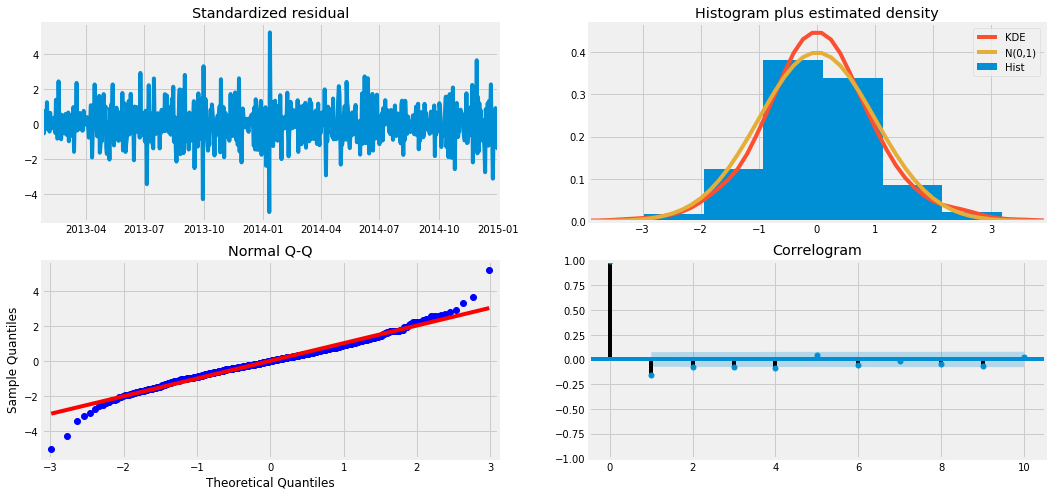

In [42]:
results.plot_diagnostics(figsize=(16, 8))
plt.show()

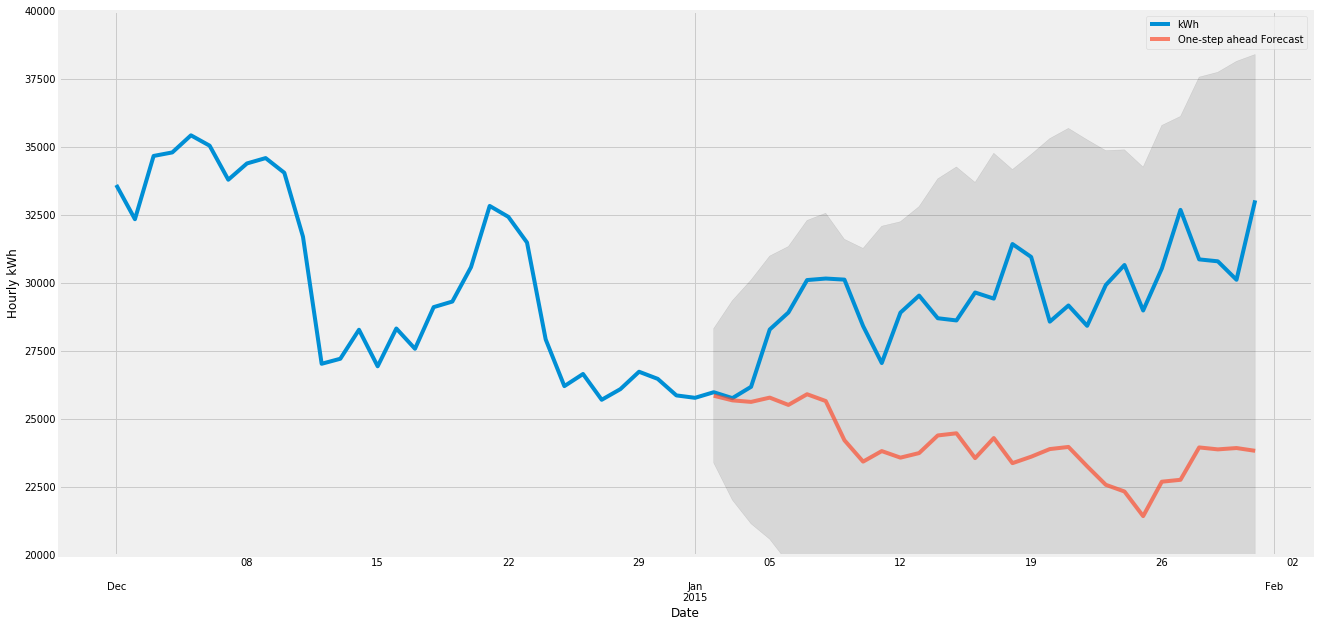

In [43]:
pred = results.get_prediction(start=test.index[0], end=test.index[-1],dynamic=True)
pred_ci = pred.conf_int(alpha = 0.1)
ax = daily_kWh['2014-12-01':].plot(label='kWh')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(20, 10))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
            
                pred_ci.iloc[:, 1], color='k', alpha=.1)
ax.set_xlabel('Date')
ax.set_ylabel('Hourly kWh')
plt.ylim([20000,40000])
plt.legend()
plt.show()

In [44]:
#Using exogenous variable (OAT)


daily_OAT = df.resample('D').mean()
exog = daily_OAT['OAT'][0:-30]
exog

timestamp
2012-10-01    72.756890
2012-10-02    76.630573
2012-10-03    65.621458
2012-10-04    61.138021
2012-10-05    62.113156
2012-10-06    61.090656
2012-10-07    59.363607
2012-10-08    59.599979
2012-10-09    61.356556
2012-10-10    59.683438
2012-10-11    57.399896
2012-10-12    57.366146
2012-10-13    59.851854
2012-10-14    61.190458
2012-10-15    63.405781
2012-10-16    67.332552
2012-10-17    67.412625
2012-10-18    70.767490
2012-10-19    63.001688
2012-10-20    60.786094
2012-10-21    57.570260
2012-10-22    56.510229
2012-10-23    55.579094
2012-10-24    57.292427
2012-10-25    58.744167
2012-10-26    61.040938
2012-10-27    63.934677
2012-10-28    62.644854
2012-10-29    58.548979
2012-10-30    57.998969
                ...    
2014-12-03    61.309531
2014-12-04    61.324677
2014-12-05    63.022271
2014-12-06    62.212490
2014-12-07    60.818544
2014-12-08    61.796264
2014-12-09    61.316365
2014-12-10    61.465445
2014-12-11    58.040847
2014-12-12    52.949052
2014-1

In [46]:
len(train)

823

In [47]:
mod2 = sm.tsa.statespace.SARIMAX(train,exog=np.asarray(exog),
                                order=(1,1,1),
                                seasonal_order=(1,2,2,28),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results2 = mod2.fit()
print(results2.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1           358.2546     12.443     28.793      0.000     333.868     382.641
ar.L1          0.5355      0.043     12.556      0.000       0.452       0.619
ma.L1         -0.8912      0.025    -35.314      0.000      -0.941      -0.842
ar.S.L28      -0.0074      0.044     -0.168      0.867      -0.094       0.079
ma.S.L28      -2.0650      0.073    -28.167      0.000      -2.209      -1.921
ma.S.L56       1.0827      0.071     15.176      0.000       0.943       1.223
sigma2      7.605e+05   8.17e+04      9.305      0.000       6e+05    9.21e+05


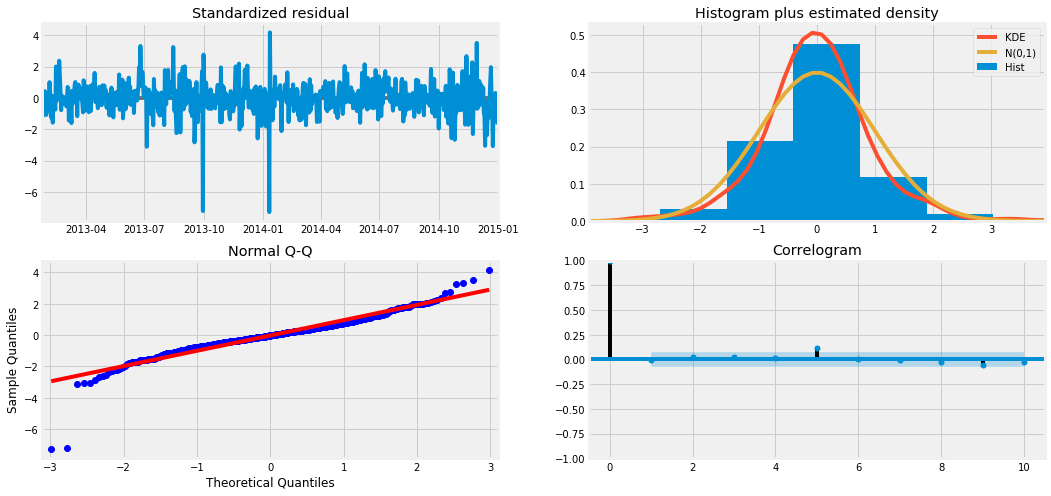

In [48]:
results2.plot_diagnostics(figsize=(16, 8))
plt.show()

In [49]:
exog_forecast = daily_OAT['OAT'][-30:]


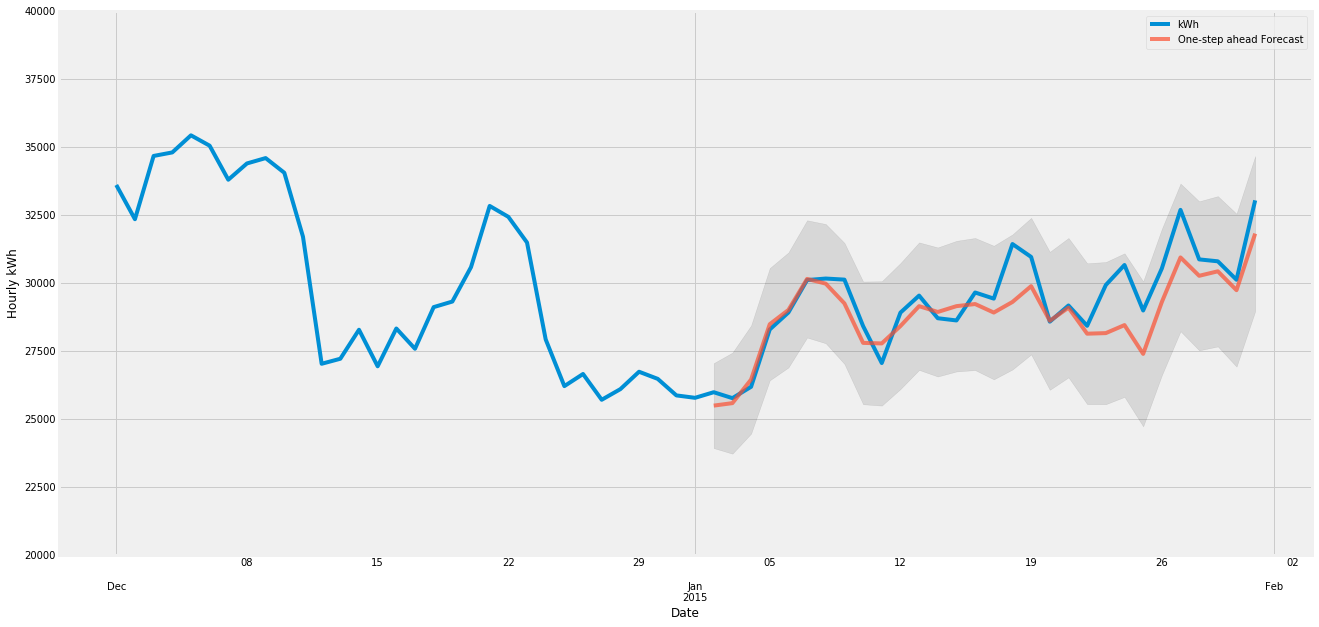

In [50]:
pred = results2.get_prediction(start=test.index[0], end=test.index[-1], exog = exog_forecast.values.astype('float64').reshape(30,1), dynamic=False)
pred_ci = pred.conf_int(alpha = 0.1)
ax = daily_kWh['2014-12-01':].plot(label='kWh')
ax
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(20, 10))
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.1)
ax.set_xlabel('Date')
ax.set_ylabel('Hourly kWh')
plt.ylim([20000,40000])
plt.legend()
plt.show()

In [51]:
pred.predicted_mean

2015-01-02    25477.937384
2015-01-03    25568.854930
2015-01-04    26436.639320
2015-01-05    28472.642353
2015-01-06    28997.618272
2015-01-07    30139.987208
2015-01-08    29964.980280
2015-01-09    29237.761158
2015-01-10    27785.742639
2015-01-11    27765.850381
2015-01-12    28405.018334
2015-01-13    29136.816120
2015-01-14    28923.155302
2015-01-15    29137.067999
2015-01-16    29215.166573
2015-01-17    28901.552269
2015-01-18    29291.458044
2015-01-19    29872.857913
2015-01-20    28597.265240
2015-01-21    29081.308852
2015-01-22    28124.039403
2015-01-23    28145.265867
2015-01-24    28439.995826
2015-01-25    27381.510758
2015-01-26    29288.631667
2015-01-27    30929.994503
2015-01-28    30253.986352
2015-01-29    30419.186303
2015-01-30    29724.570999
2015-01-31    31806.073569
Freq: D, dtype: float64

In [52]:
np.sqrt(mean_squared_error(test,pred.predicted_mean))

937.3521745002882

In [58]:
np.mean(test)

29390.364533333326

In [60]:
np.sqrt(mean_squared_error(test,pred.predicted_mean))/np.mean(test)*100

3.189317959759167